# Polynomial Regression

## 1. Recap: Linear Regression
- **Simple Linear Regression:**  
  

\[
  y = mx + c
  \]

  
  - One slope \(m\), one variable \(x\), one intercept \(c\).  
  - Fits a straight line through the data.

- **Multiple Linear Regression:**  
  

\[
  y = m_1x_1 + m_2x_2 + \..... + m_nx_n + c
  \]

  
  - Many slopes (\(m_1, m_2, \....., m_n\)), many variables (\(x_1, x_2, \....., x_n\)), one intercept \(c\).  
  - Fits a hyperplane in higher dimensions.

---

## 2. Polynomial Regression
Polynomial Regression is simply an **extension of linear regression** where we add **powers of the same variable** to capture non‑linear trends.

- Formula (for one variable \(x\)):  
  

\[
  y = m_1x + m_2x^2 + m_3x^3 + \..... + m_nx^n + c
  \]



- Notice the difference:
  - Linear regression: only \(x\) (first power).  
  - Polynomial regression: includes \(x^2, x^3, \dots, x^n\).  
  - Still uses the same idea of slopes (\(m\)) and intercept (\(c\)), but now the model can bend and curve to fit data better.

---

## 3. Why Polynomial Regression?
- Some relationships are **not straight lines**.  
- Example: In your dataset (Position, Level, Salary), salaries grow slowly at first, then explode at higher levels (CEO).  
- A straight line \(y = mx + c\) cannot capture this sharp curve.  
- Polynomial regression allows the line to bend and follow the data trend.

---

## 4. Dataset Example
| Position          | Level | Salary   |
|-------------------|-------|----------|
| Business Analyst  | 1     | 45,000   |
| Junior Consultant | 2     | 50,000   |
| Senior Consultant | 3     | 60,000   |
| Manager           | 4     | 80,000   |
| Country Manager   | 5     | 110,000  |
| Region Manager    | 6     | 150,000  |
| Partner           | 7     | 200,000  |
| Senior Partner    | 8     | 300,000  |
| C-level           | 9     | 500,000  |
| CEO               | 10    | 1,000,000|

- If we try **linear regression**:  
  

\[
  y = mx + c
  \]

  
  → The line will underpredict high salaries (CEO, C-level (C‑level = the group of senior executives with “Chief” in their title.)).  

- If we try **polynomial regression**:  
  

\[
  y = m_1x + m_2x^2 + m_3x^3 + \... + c
  \]

  
  → The curve bends upward, capturing the rapid salary growth at higher levels.

---

## 5. Key Insight
Polynomial regression is **still linear regression in disguise** , because the coefficients (\(m_1, m_2, \dots\)) are solved using the same linear algebra.  
The only difference is that we feed the model **extra features**: \(x^2, x^3, \dots\).

---


In [2]:
# Importing the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
# Importing the dataset
dataset = pd.read_csv('Position_Salaries.csv')

# Independent variable(s): here it's the "Level" column
X = dataset.iloc[:, 1:-1].values

# Dependent variable: here it's the "Salary" column
y = dataset.iloc[:, -1].values


In [4]:
dataset

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000
5,Region Manager,6,150000
6,Partner,7,200000
7,Senior Partner,8,300000
8,C-level,9,500000
9,CEO,10,1000000


In [3]:
# Training the Linear Regression model on the whole dataset


from sklearn.linear_model import LinearRegression

# Step 1: Create the Linear Regression model object
lin_reg = LinearRegression()

# Step 2: Fit (train) the model on the dataset
lin_reg.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [5]:
# Training the Polynomial Regression model on the whole dataset

# Step 1: Import the PolynomialFeatures class
# This will generate new features like x^2, x^3, ... up to the chosen degree
from sklearn.preprocessing import PolynomialFeatures

# Step 2: Create a PolynomialFeatures object with degree = 4
# Degree controls how flexible the curve is (higher degree = more bending)
poly_reg = PolynomialFeatures(degree=4)

# Step 3: Transform the original feature X (Level) into polynomial features
# Example: if X = [[2]], it becomes [[1, 2, 4, 8, 16]] for degree=4
X_poly = poly_reg.fit_transform(X)

# Step 4: Create a LinearRegression object
# Even though we call it "linear regression," it works because the polynomial
# transformation has already created extra features (x^2, x^3, etc.)
from sklearn.linear_model import LinearRegression
lin_reg_2 = LinearRegression()

# Step 5: Fit the polynomial regression model on the transformed data
# This finds the best-fit curve that matches the salary growth pattern
lin_reg_2.fit(X_poly, y)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


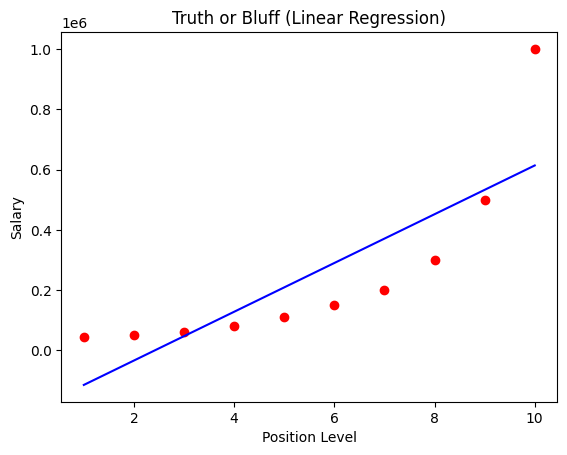

In [6]:
# Visualising the Linear Regression results

# Step 1: Plot the actual data points
# X = Position Levels, y = Salaries
# Red dots show the real dataset values
plt.scatter(X, y, color='red')

# Step 2: Plot the regression line
# lin_reg.predict(X) gives the predicted salaries for each level
# Blue line shows the straight line fit from Linear Regression
plt.plot(X, lin_reg.predict(X), color='blue')

# Step 3: Add chart details
plt.title('Truth or Bluff (Linear Regression)')   # Title of the plot
plt.xlabel('Position Level')                      # X-axis label
plt.ylabel('Salary')                              # Y-axis label

# Step 4: Display the plot
plt.show()


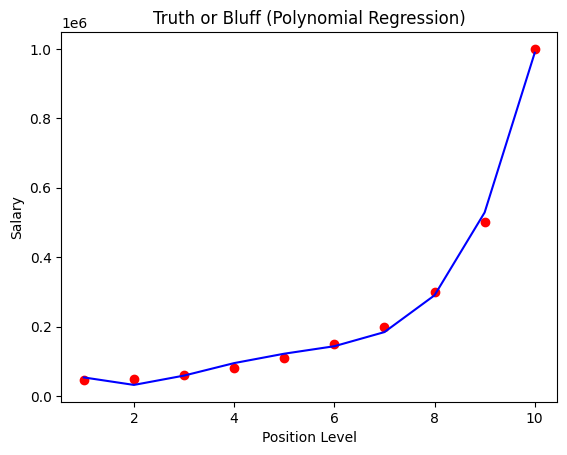

In [7]:
# Visualising the Polynomial Regression results

# Step 1: Plot the actual data points
# Red dots represent the real dataset values (Levels vs Salaries)
plt.scatter(X, y, color='red')

# Step 2: Plot the polynomial regression curve
# poly_reg.fit_transform(X) expands X into polynomial features (x, x^2, x^3, x^4)
# lin_reg_2.predict(...) then predicts salaries using the trained polynomial model
# Blue curve shows how the polynomial regression bends to fit the data
plt.plot(X, lin_reg_2.predict(poly_reg.fit_transform(X)), color='blue')

# Step 3: Add chart details
plt.title('Truth or Bluff (Polynomial Regression)')   # Title of the plot
plt.xlabel('Position Level')                          # X-axis label
plt.ylabel('Salary')                                  # Y-axis label

# Step 4: Display the plot
plt.show()


In [10]:
# Predicting a new result with Linear Regression

# We trained lin_reg earlier on the dataset (Levels vs Salaries).
# Now we want to predict the salary for a new Level = 6.5
lin_reg.predict([[6.5]])

array([330378.78787879])

In [ ]:
# Compare actual vs predicted salaries using Polynomial Regression

# Step 1: Predict salaries for all levels using the polynomial model
y_pred_poly = lin_reg_2.predict(poly_reg.fit_transform(X))

# Step 2: Build a DataFrame for comparison

comparison = pd.DataFrame({
    'Level': X[:, 0],                          # Take the first column directly
    'Actual Salary': y,                        # Actual salaries
    'Predicted Salary (Poly)': y_pred_poly.round(2)  # Predicted salaries (rounded)
})

print(comparison)

   Level  Actual Salary  Predicted Salary (Poly)
0      1          45000                 53356.64
1      2          50000                 31759.91
2      3          60000                 58642.19
3      4          80000                 94632.87
4      5         110000                121724.94
5      6         150000                143275.06
6      7         200000                184003.50
7      8         300000                289994.17
8      9         500000                528694.64
9     10        1000000                988916.08


: 

In [11]:
# Predicting a new result with Polynomial Regression

# Step 1: Transform the new input (Level = 6.5) into polynomial features
# For degree=4, [[6.5]] becomes [1, 6.5, (6.5)^2, (6.5)^3, (6.5)^4]
# i.e. [1, 6.5, 42.25, 274.625, 1785.0625]

X_test_poly = poly_reg.fit_transform([[6.5]])

# Step 2: Use the trained polynomial regression model to predict salary
lin_reg_2.predict(X_test_poly)

array([158862.45265155])

In [7]:
import pandas as pd
import numpy as np
import gradio as gr
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Step 1: Import dataset
dataset = pd.read_csv('Position_Salaries.csv')
X = dataset.iloc[:, 1:-1].values   # Level column
y = dataset.iloc[:, -1].values     # Salary column

# Step 2: Train Polynomial Regression model
poly_reg = PolynomialFeatures(degree=4)
X_poly = poly_reg.fit_transform(X)

lin_reg_2 = LinearRegression()
lin_reg_2.fit(X_poly, y)

# Step 3: Define prediction function
def predict_salary(level):
    # Transform the input level into polynomial features
    level_poly = poly_reg.transform([[level]])
    prediction = lin_reg_2.predict(level_poly)
    return f"Predicted Salary for Level {level}: {prediction[0]:,.2f}"

# Step 4: Create Gradio interface
app = gr.Interface(
    fn=predict_salary,
    inputs=gr.Number(label="Enter Position Level"),
    outputs="text",
    title="Salary Predictor (Polynomial Regression)",
    description="Enter a job level (e.g., 6.5) to predict the salary using a polynomial regression model."
)

# Step 5: Launch the app
app.launch()


* Running on local URL:  http://127.0.0.1:7862
* To create a public link, set `share=True` in `launch()`.


# Interpreting Regression Predictions

## 1. Prediction Results
- **Linear Regression Prediction (Level = 6.5):**
  

\[
  \text{Predicted Salary} \approx 330,379
  \]


  - Straight line fit overshoots the actual salary trend.
  - Linear regression cannot capture the sharp rise at higher levels.

- **Polynomial Regression Prediction (Level = 6.5, degree=4):**
  

\[
  \text{Predicted Salary} \approx 158,862
  \]


  - Curved fit bends closer to the actual salary progression.
  - Polynomial regression adapts to the non-linear growth pattern.

---

## 2. When to Use What

###  Simple Linear Regression
- Formula: 

\[
  y = mx + c
  \]


- Use when:
  - Only **one independent variable**.
  - Relationship is roughly **straight line**.
- Example: Predicting house price from size (if growth is linear).

---

###  Multiple Linear Regression
- Formula: 

\[
  y = m_1x_1 + m_2x_2 + \dots + m_nx_n + c
  \]


- Use when:
  - **More than one independent variable**.
  - Relationship is still linear in each variable.
- Example: Predicting salary using **experience + education + age**.

---

###  Polynomial Regression
- Formula: 

\[
  y = m_1x + m_2x^2 + m_3x^3 + \dots + m_nx^n + c
  \]


- Use when:
  - Relationship is **non-linear** (curved).
  - One variable, but the effect grows faster/slower at different ranges.
- Example: Predicting salary from **position level**, where growth accelerates sharply at higher levels (C-level, CEO).

---

## 3. Final Insight
- **Linear Regression** is simple but fails when data has curves.  
- **Multiple Linear Regression** is powerful when many factors influence the outcome.  
- **Polynomial Regression** is best when one factor drives a **non-linear trend**.  

 In our dataset, **Polynomial Regression** is the right choice because salary growth is **non-linear** with respect to position level.

In [9]:
pip install flask

  Using cached blinker-1.9.0-py3-none-any.whl.metadata (1.6 kB)
Using cached blinker-1.9.0-py3-none-any.whl (8.5 kB)

   ---------------------------------------- 0/4 [werkzeug]
   ---------------------------------------- 0/4 [werkzeug]
   ---------------------------------------- 0/4 [werkzeug]
   ---------------------------------------- 0/4 [werkzeug]
   ---------- ----------------------------- 1/4 [itsdangerous]
   ------------------------------ --------- 3/4 [flask]
   ------------------------------ --------- 3/4 [flask]
   ---------------------------------------- 4/4 [flask]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\admin\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip
